In [1]:
import pandas as pd

In [4]:
tcga_train = pd.read_csv('strat.csv')

In [7]:
set(tcga_train['project_id_x'])

{'TCGA-BRCA',
 'TCGA-COAD',
 'TCGA-HNSC',
 'TCGA-KICH',
 'TCGA-KIRC',
 'TCGA-KIRP',
 'TCGA-LUAD',
 'TCGA-LUSC',
 'TCGA-PAAD',
 'TCGA-READ'}

In [32]:
len(tcga_train['ID'])

1594

In [31]:
len(set(tcga_train['ID']))

1594

### Plot stacked tissue by stage and age

In [11]:
tcga_train.head()

,Unnamed: 0.2,Unnamed: 0.1,case_id,project_id_x,Stage,Age,case_submitter_id_x,Cancer,vital_status,days_to_death,...,project_id_2,project_id_8,project_id_3,project_id_5,stratify_col,test,RNA_Bio_ter,RNA_Bio_ter_low,RNA_Bio_ter_mid,RNA_Bio_ter_high
0,0,0,ff8dac97-42ff-4f48-81c4-50315ad8de58,TCGA-PAAD,1,0,TCGA-FB-AAQ1,8,Dead,123.0,...,0,1,0,0,0-1-0-0-1-0-0,6,2,0,0,1
1,1,1,3e1886a8-2ed2-41ee-8b58-10f5321ade6f,TCGA-COAD,1,2,TCGA-DM-A28K,1,Alive,NaN,...,0,0,0,0,0-1-0-0-0-0-1,1,1,0,1,0
2,2,2,4b22ad71-c585-4077-ad3c-c6e026d0c7fa,TCGA-LUAD,1,1,TCGA-44-7669,6,Dead,574.0,...,0,0,0,0,0-1-0-0-0-1-0,0,0,1,0,0
3,3,3,452135f2-6de6-4593-a091-ddf6344ee431,TCGA-KICH,1,1,TCGA-KL-8328,3,Alive,NaN,...,0,0,1,0,0-1-0-0-0-1-0,6,0,1,0,0
4,4,4,93b742eb-5fc3-4ce2-b7f6-c89f97e0dcc9,TCGA-HNSC,1,1,TCGA-CV-7263,2,Dead,560.0,...,1,0,0,0,0-1-0-0-0-1-0,2,1,0,1,0


In [76]:
tcga_train['Stage'] = tcga_train['Stage'].replace({0:1,1:2,2:3,3:4})

In [8]:
tcga_train.columns

Index(['Unnamed: 0.2', 'Unnamed: 0.1', 'case_id', 'project_id_x', 'Stage',
       'Age', 'case_submitter_id_x', 'Cancer', 'vital_status', 'days_to_death',
       'days_to_last_follow_up', '18_months', '24_months', '36_months',
       'Survival', '120_months', 'ID', 'RNA_Bio', 'RNA_Bio_z', 'RNA_Bio_bin',
       'Unnamed: 0', 'stage_var_0', 'stage_var_1', 'stage_var_2',
       'stage_var_3', 'age_group_2', 'age_group_1', 'age_group_0',
       'project_id_9', 'project_id_0', 'project_id_4', 'project_id_7',
       'project_id_6', 'project_id_1', 'project_id_2', 'project_id_8',
       'project_id_3', 'project_id_5', 'stratify_col', 'test', 'RNA_Bio_ter',
       'RNA_Bio_ter_low', 'RNA_Bio_ter_mid', 'RNA_Bio_ter_high'],
      dtype='object')

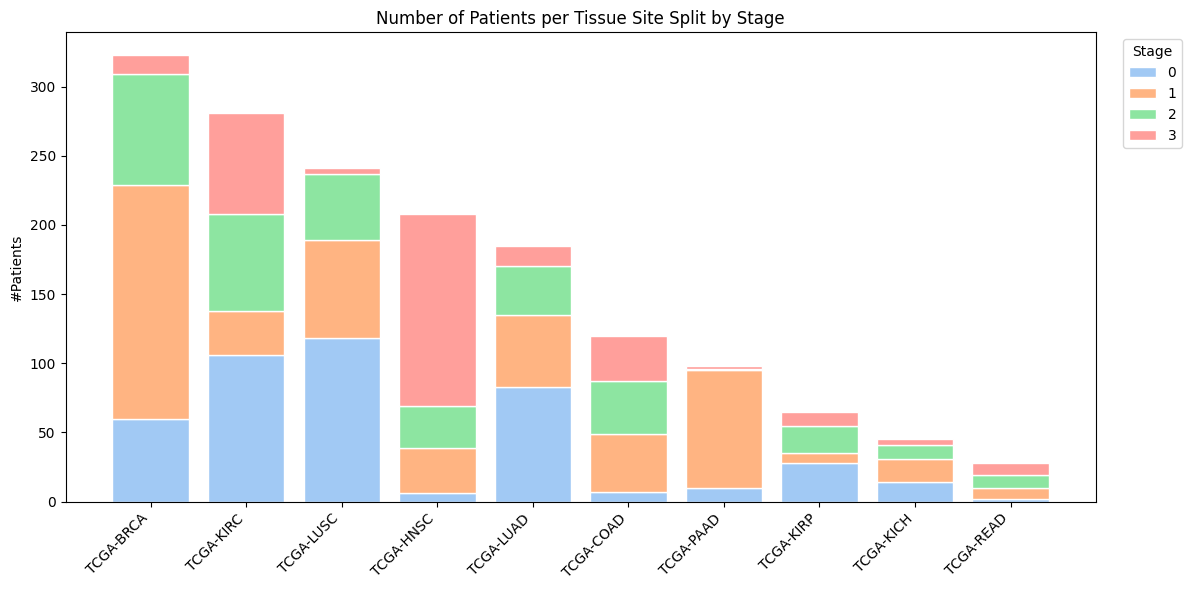

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Settings you can tweak ---
csv_path = "strat.csv"               # or the full path to your file
tissue_col = "project_id_x"          # tissue site column
stage_col = "Stage"                  # stage column
#out_path = "tissue_by_stage_stacked.png"
figsize = (12, 6)                    # figure size (inches)
rotation = 45                        # x-axis tick rotation
dpi = 300                            # export dpi
# --------------------------------

# Load data
df = pd.read_csv(csv_path)

# Keep rows with both Tissue and Stage present
tmp = df[[tissue_col, stage_col]].dropna()
tmp[stage_col] = tmp[stage_col].astype(str)  # ensure categorical-like strings

# Build counts matrix: rows=tissue sites, cols=stages
pivot = pd.pivot_table(
    tmp, index=tissue_col, columns=stage_col, aggfunc="size", fill_value=0
)

# Sort tissue sites by total count (descending) for readability
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

palette = sns.color_palette("pastel", n_colors=len(pivot.columns))

# Plot stacked bars
fig, ax = plt.subplots(figsize=(12,6))
x = np.arange(len(pivot))
bottom = np.zeros(len(pivot))

for color, stage in zip(palette, pivot.columns):
    values = pivot[stage].values
    ax.bar(x, values, bottom=bottom, label=stage, color=color, edgecolor="white")
    bottom += values

plt.title("Number of Patients per Tissue Site Split by Stage")
plt.xlabel("")
plt.ylabel("#Patients")
plt.xticks(x, pivot.index, rotation=rotation, ha="right")
plt.legend(title="Stage", bbox_to_anchor=(1.02, 1), loc="upper left")  # legend outside
plt.tight_layout()

# Save high-DPI figure for slides
#plt.savefig(out_path, dpi=dpi, bbox_inches="tight")
plt.show()
#print(f"Saved figure to: {out_path}")


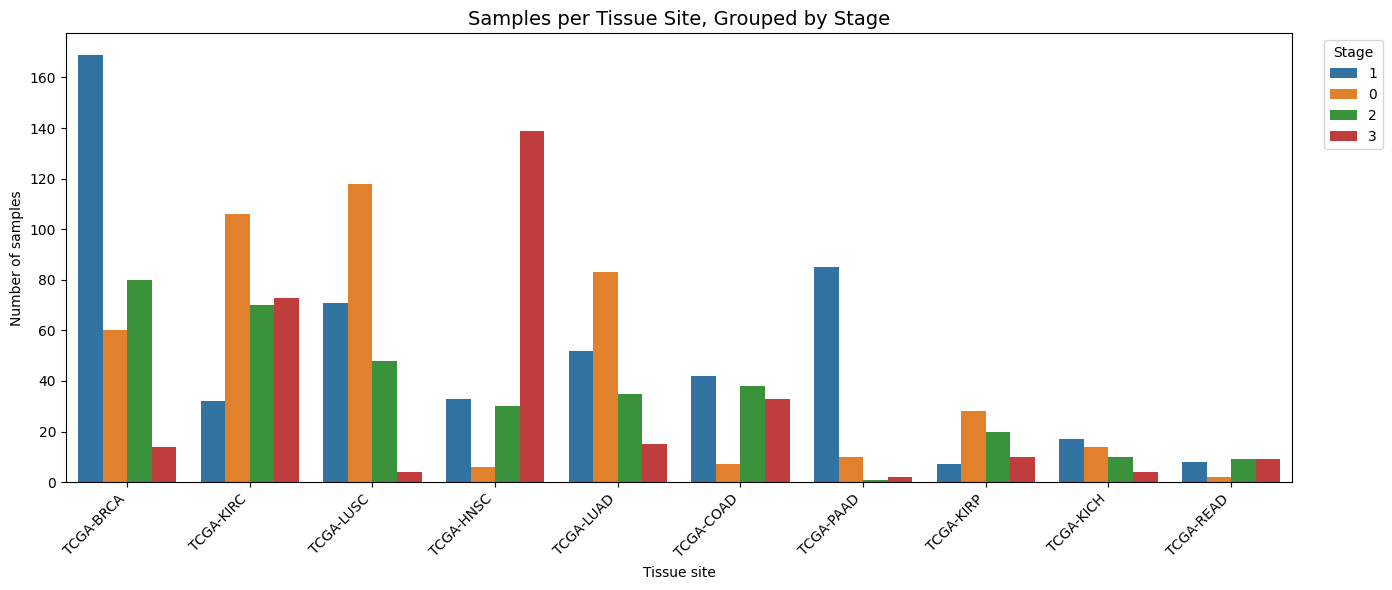

In [16]:
pivot

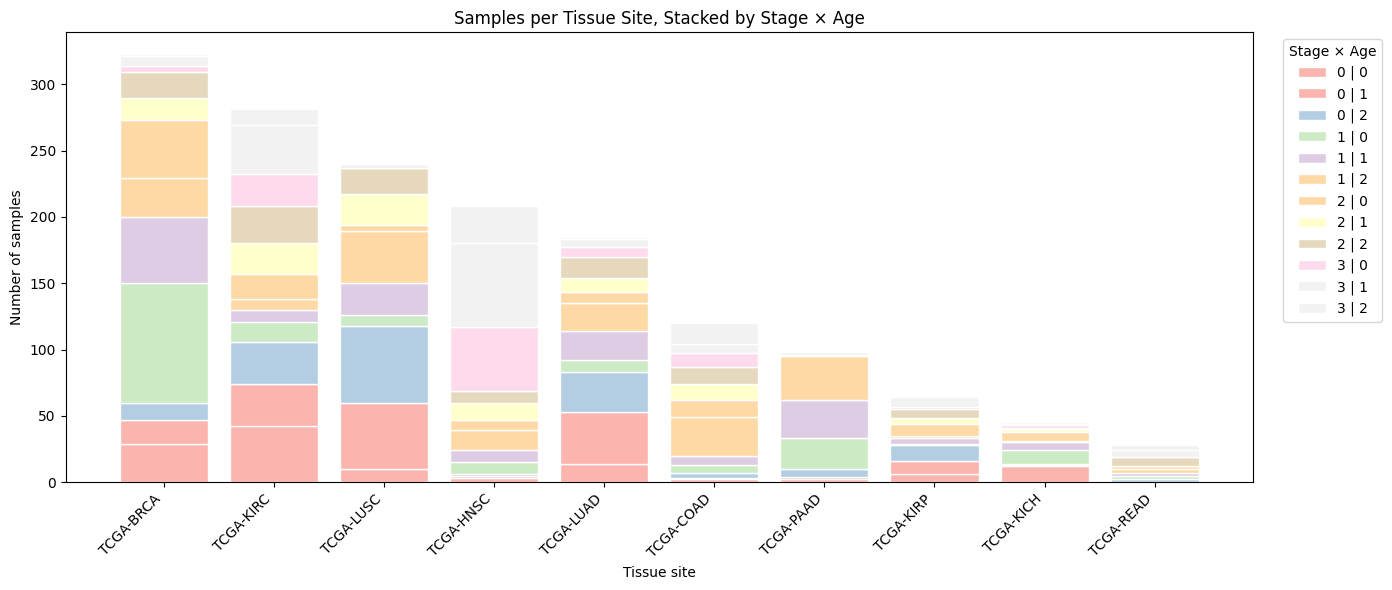

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("strat.csv")
tissue_col = "project_id_x"
stage_col = "Stage"
age_col = "Age"   # categorical already

# Drop rows with missing values in either Stage or Age
tmp = df[[tissue_col, stage_col, age_col]].dropna()
tmp[stage_col] = tmp[stage_col].astype(str)
tmp[age_col]   = tmp[age_col].astype(str)

# Combine Stage + Age into a single label
tmp["Stage_Age"] = tmp[stage_col] + " | " + tmp[age_col]

# Pivot counts
pivot = pd.pivot_table(
    tmp, index=tissue_col, columns="Stage_Age", aggfunc="size", fill_value=0
)
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

# Colors (e.g. from Pastel1 colormap)
cmap = plt.get_cmap("Pastel1")
colors = cmap(np.linspace(0, 1, len(pivot.columns)))

fig, ax = plt.subplots(figsize=(14,6))
x = np.arange(len(pivot))
bottom = np.zeros(len(pivot))

for color, cat in zip(colors, pivot.columns):
    ax.bar(x, pivot[cat].values, bottom=bottom, label=cat, color=color, edgecolor="white")
    bottom += pivot[cat].values

ax.set_title("Samples per Tissue Site, Stacked by Stage × Age")
ax.set_xlabel("Tissue site")
ax.set_ylabel("Number of samples")
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=45, ha="right")
ax.legend(title="Stage × Age", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


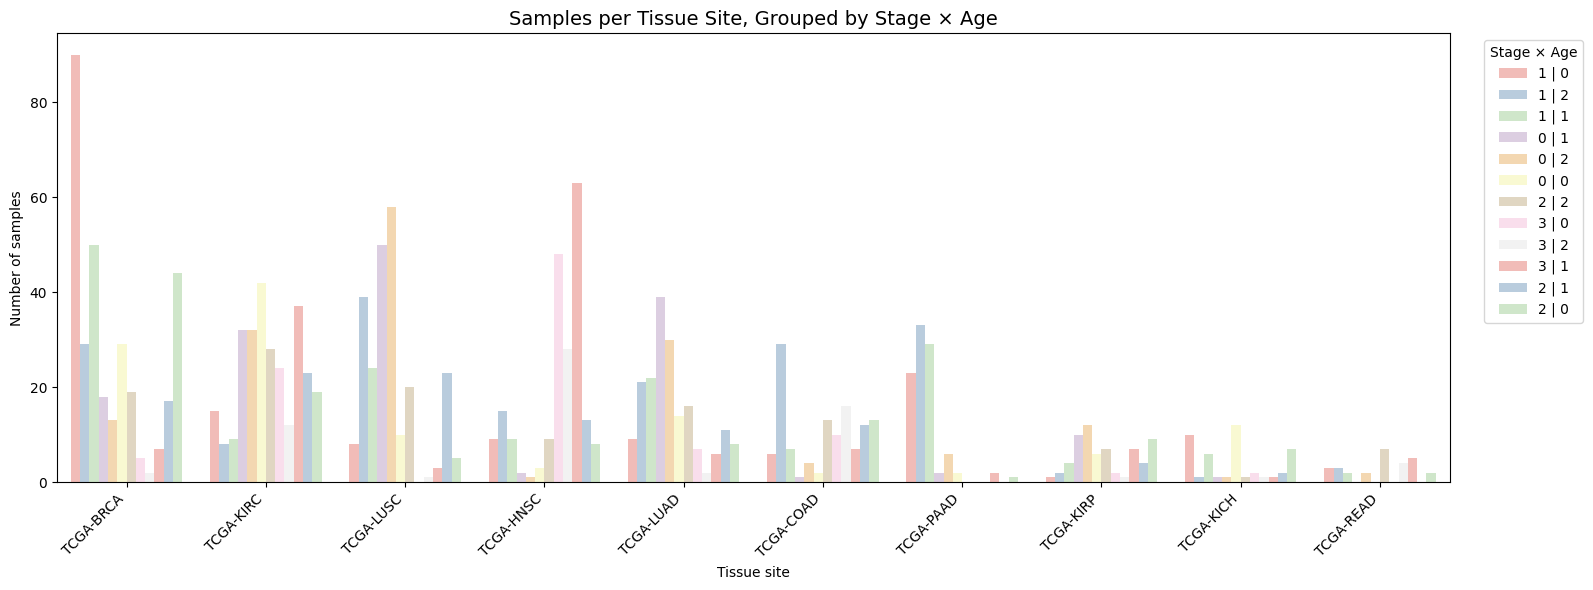

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("strat.csv")
tissue_col = "project_id_x"
stage_col = "Stage"
age_col = "Age"

# Drop NAs
tmp = df[[tissue_col, stage_col, age_col]].dropna()
tmp[stage_col] = tmp[stage_col].astype(str)
tmp[age_col]   = tmp[age_col].astype(str)

# Composite category
tmp["Stage_Age"] = tmp[stage_col] + " | " + tmp[age_col]

# Order tissues by size
order = tmp[tissue_col].value_counts().index

plt.figure(figsize=(16, 6))
sns.countplot(
    data=tmp,
    x=tissue_col,
    hue="Stage_Age",
    order=order,
    palette="Pastel1"
)

plt.title("Samples per Tissue Site, Grouped by Stage × Age", fontsize=14)
plt.xlabel("Tissue site")
plt.ylabel("Number of samples")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Stage × Age", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


NameError: name 'age_label_' is not defined

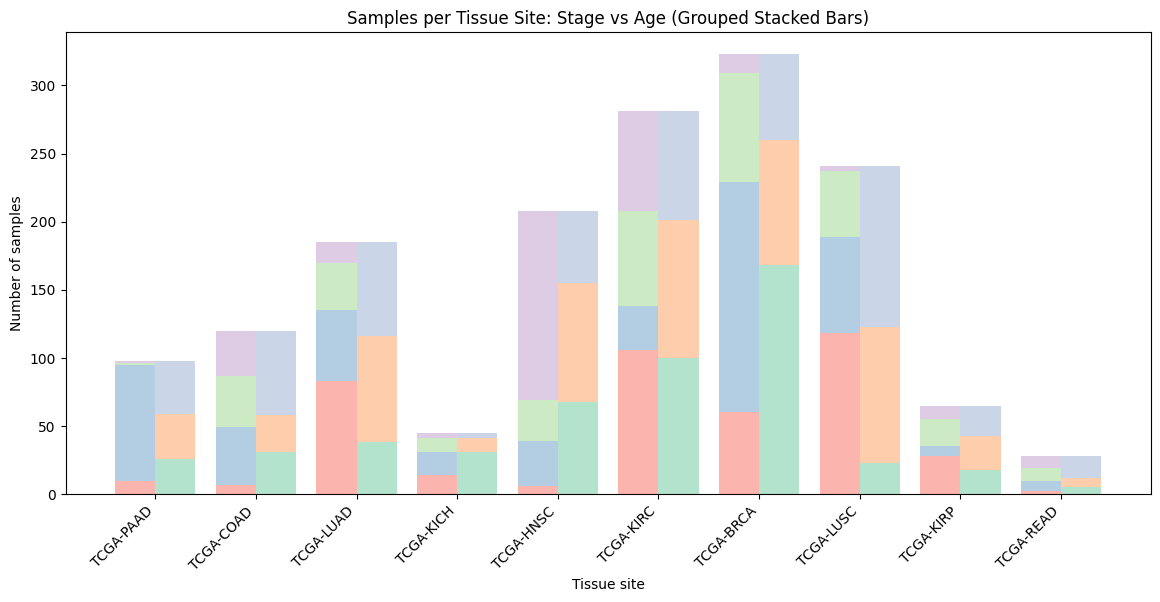

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("strat.csv")
tissue_col = "project_id_x"
stage_col = "Stage"
age_col = "Age"

# --- Prepare pivots ---
tmp_stage = df[[tissue_col, stage_col]].dropna()
tmp_stage[stage_col] = tmp_stage[stage_col].astype(str)
pivot_stage = pd.pivot_table(tmp_stage, index=tissue_col, columns=stage_col, aggfunc="size", fill_value=0)

tmp_age = df[[tissue_col, age_col]].dropna()
tmp_age[age_col] = tmp_age[age_col].astype(str)
pivot_age = pd.pivot_table(tmp_age, index=tissue_col, columns=age_col, aggfunc="size", fill_value=0)

# Align indices
tissues = df[tissue_col].dropna().unique()
pivot_stage = pivot_stage.reindex(tissues, fill_value=0)
pivot_age = pivot_age.reindex(tissues, fill_value=0)

# --- Plot ---
fig, ax = plt.subplots(figsize=(14,6))
x = np.arange(len(tissues))

# Colors
stage_colors = sns.color_palette("Pastel1", n_colors=len(pivot_stage.columns))
age_colors   = sns.color_palette("Pastel2", n_colors=len(pivot_age.columns))

# Stage stacked (shift left)
bottom = np.zeros(len(tissues))
for color, col in zip(stage_colors, pivot_stage.columns):
    ax.bar(x - 0.2, pivot_stage[col].values, bottom=bottom, color=color, width=0.4, label=f"Stage: {col}")
    bottom += pivot_stage[col].values

# Age stacked (shift right)
bottom = np.zeros(len(tissues))
for color, col in zip(age_colors, pivot_age.columns):
    ax.bar(x + 0.2, pivot_age[col].values, bottom=bottom, color=color, width=0.4, label=f"Age: {col}")
    bottom += pivot_age[col].values

# Labels
ax.set_title("Samples per Tissue Site: Stage vs Age (Grouped Stacked Bars)")
ax.set_xlabel("Tissue site")
ax.set_ylabel("Number of samples")
ax.set_xticks(x)
ax.set_xticklabels(tissues, rotation=45, ha="right")

# Legends (two separate for clarity)
handles, labels = ax.get_legend_handles_labels()
stage_handles = [h for h,l in zip(handles, labels) if l.startswith("Stage:")]
stage_labels  = [l for l in labels if l.startswith("Stage:")]
age_handles   = [h for h,l in zip(handles, labels) if l.startswith("Age:")]
age_label_


AttributeError: 'NoneType' object has no attribute 'create_artists'

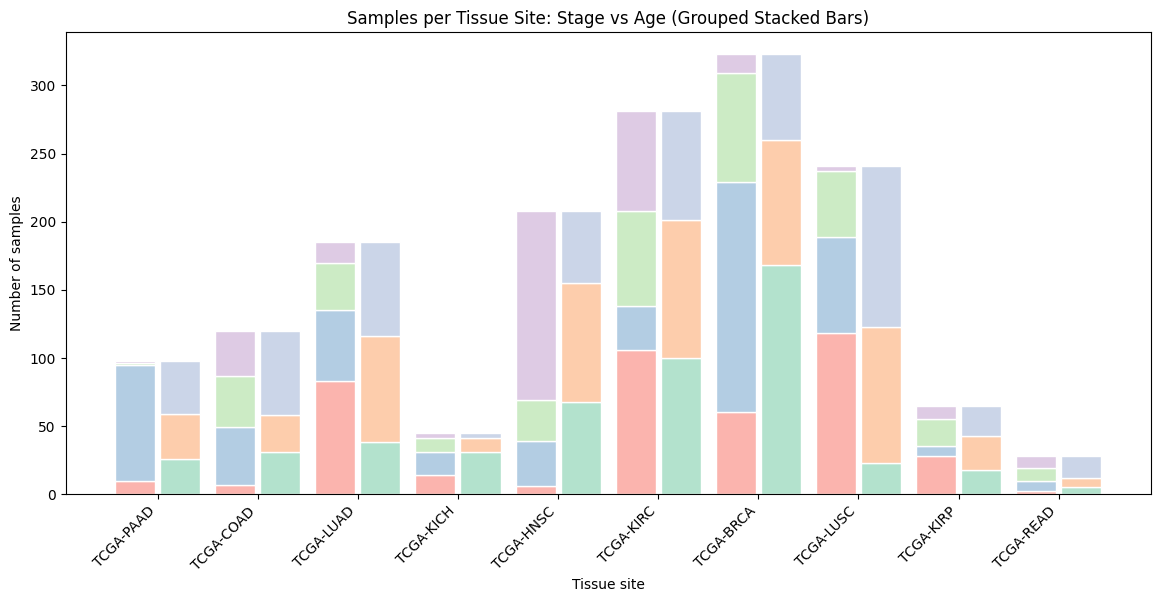

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load data ---
df = pd.read_csv("strat.csv")
tissue_col = "project_id_x"
stage_col = "Stage"
age_col = "Age"

# --- Prepare stage pivot ---
tmp_stage = df[[tissue_col, stage_col]].dropna()
tmp_stage[stage_col] = tmp_stage[stage_col].astype(str)
pivot_stage = pd.pivot_table(
    tmp_stage, index=tissue_col, columns=stage_col, aggfunc="size", fill_value=0
)

# --- Prepare age pivot ---
tmp_age = df[[tissue_col, age_col]].dropna()
tmp_age[age_col] = tmp_age[age_col].astype(str)
pivot_age = pd.pivot_table(
    tmp_age, index=tissue_col, columns=age_col, aggfunc="size", fill_value=0
)

# --- Align indices (so both pivots have the same tissues in the same order) ---
tissues = df[tissue_col].dropna().unique()
pivot_stage = pivot_stage.reindex(tissues, fill_value=0)
pivot_age = pivot_age.reindex(tissues, fill_value=0)

# --- Colors ---
stage_colors = sns.color_palette("Pastel1", n_colors=len(pivot_stage.columns))
age_colors   = sns.color_palette("Pastel2", n_colors=len(pivot_age.columns))

# --- Plot ---
fig, ax = plt.subplots(figsize=(14,6))
x = np.arange(len(tissues))

bar_width = 0.4    # width of each stack
gap = 0.05           # gap between the two bars

offset = bar_width/2 + gap/2  # symmetric offset from center

# Stage stacked (left group)
bottom = np.zeros(len(tissues))
for color, col in zip(stage_colors, pivot_stage.columns):
    ax.bar(x - offset, pivot_stage[col].values, bottom=bottom,
           color=color, width=bar_width, edgecolor="white")
    bottom += pivot_stage[col].values

# Age stacked (right group)
bottom = np.zeros(len(tissues))
for color, col in zip(age_colors, pivot_age.columns):
    ax.bar(x + offset, pivot_age[col].values, bottom=bottom,
           color=color, width=bar_width, edgecolor="white")
    bottom += pivot_age[col].values

# Labels and ticks
ax.set_title("Samples per Tissue Site: Stage vs Age (Grouped Stacked Bars)")
ax.set_xlabel("Tissue site")
ax.set_ylabel("Number of samples")
ax.set_xticks(x)
ax.set_xticklabels(tissues, rotation=45, ha="right")

# Legends (split: Stage vs Age)
handles, labels = ax.get_legend_handles_labels()
stage_handles = [h for h,l in zip(handles, labels) if l in [f"Stage: {c}" for c in pivot_stage.columns]]
stage_labels  = [f"Stage: {c}" for c in pivot_stage.columns]
age_handles   = [h for h,l in zip(handles, labels) if l in [f"Age: {c}" for c in pivot_age.columns]]
age_labels    = [f"Age: {c}" for c in pivot_age.columns]

# Custom legends
legend1 = ax.legend(stage_colors, stage_labels, title="Stage",
                    bbox_to_anchor=(1.02, 1), loc="upper left")
ax.add_artist(legend1)
ax.legend(age_colors, age_labels, title="Age",
          bbox_to_anchor=(1.02, 0.5), loc="upper left")

plt.tight_layout()
plt.show()


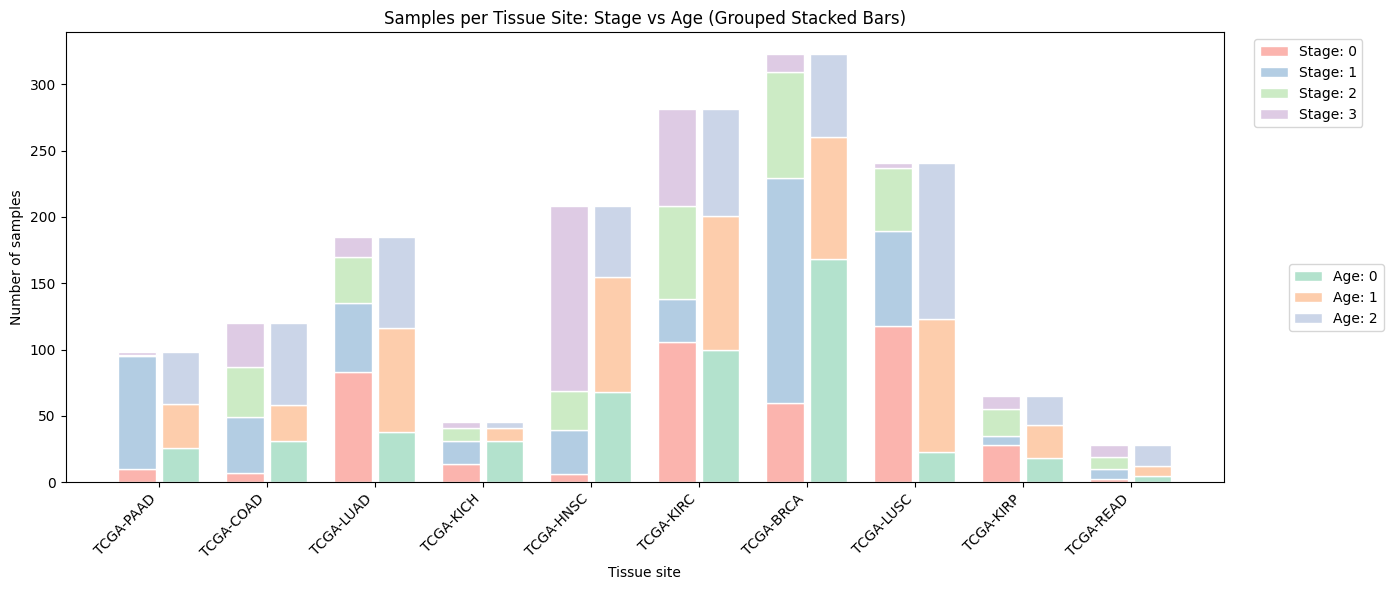

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load data ---
df = pd.read_csv("strat.csv")
tissue_col = "project_id_x"
stage_col = "Stage"
age_col = "Age"

# --- Prepare stage pivot ---
tmp_stage = df[[tissue_col, stage_col]].dropna()
tmp_stage[stage_col] = tmp_stage[stage_col].astype(str)
pivot_stage = pd.pivot_table(
    tmp_stage, index=tissue_col, columns=stage_col, aggfunc="size", fill_value=0
)

# --- Prepare age pivot ---
tmp_age = df[[tissue_col, age_col]].dropna()
tmp_age[age_col] = tmp_age[age_col].astype(str)
pivot_age = pd.pivot_table(
    tmp_age, index=tissue_col, columns=age_col, aggfunc="size", fill_value=0
)

# --- Align tissue sites ---
tissues = df[tissue_col].dropna().unique()
pivot_stage = pivot_stage.reindex(tissues, fill_value=0)
pivot_age   = pivot_age.reindex(tissues, fill_value=0)

# --- Colors ---
stage_colors = sns.color_palette("Pastel1", n_colors=len(pivot_stage.columns))
age_colors   = sns.color_palette("Pastel2", n_colors=len(pivot_age.columns))

# --- Plot ---
fig, ax = plt.subplots(figsize=(14,6))
x = np.arange(len(tissues))

bar_width = 0.35
gap = 0.05
offset = bar_width/2 + gap/2  # ensures even spacing

# Stage stacked (left bars)
bottom = np.zeros(len(tissues))
for color, col in zip(stage_colors, pivot_stage.columns):
    ax.bar(x - offset, pivot_stage[col].values, bottom=bottom,
           width=bar_width, color=color, edgecolor="white", label=f"Stage: {col}")
    bottom += pivot_stage[col].values

# Age stacked (right bars)
bottom = np.zeros(len(tissues))
for color, col in zip(age_colors, pivot_age.columns):
    ax.bar(x + offset, pivot_age[col].values, bottom=bottom,
           width=bar_width, color=color, edgecolor="white", label=f"Age: {col}")
    bottom += pivot_age[col].values

# Labels and ticks
ax.set_title("Samples per Tissue Site: Stage vs Age (Grouped Stacked Bars)")
ax.set_xlabel("Tissue site")
ax.set_ylabel("Number of samples")
ax.set_xticks(x)
ax.set_xticklabels(tissues, rotation=45, ha="right")

# Legends (build cleanly, no error)
from matplotlib.patches import Patch

# Legends
stage_labels = [f"Stage: {c}" for c in pivot_stage.columns]
age_labels   = [f"Age: {c}" for c in pivot_age.columns]

stage_handles = [Patch(facecolor=color, edgecolor="white") 
                 for color in stage_colors]
age_handles   = [Patch(facecolor=color, edgecolor="white") 
                 for color in age_colors]

legend1 = ax.legend(stage_handles, stage_labels, title="",
                    bbox_to_anchor=(1.02, 1), loc="upper left")
ax.add_artist(legend1)  # keep stage legend
ax.legend(age_handles, age_labels, title="",
          bbox_to_anchor=(1.05, 0.5), loc="upper left")


plt.tight_layout()
plt.show()


In [62]:
# --- Mapping from TCGA code to disease site ---
tcga_map = {
    "TCGA-BRCA": "Breast",
    "TCGA-COAD": "Colon",
    "TCGA-HNSC": "Head and Neck",
    "TCGA-KICH": "Kidney Chromophobe",
    "TCGA-KIRC": "Kidney Clear Cell",
    "TCGA-KIRP": "Kidney Papillary",
    "TCGA-LUAD": "Lung Adenocarcinoma",
    "TCGA-LUSC": "Lung Squamous",
    "TCGA-PAAD": "Pancreatic",
    "TCGA-READ": "Rectal"
}

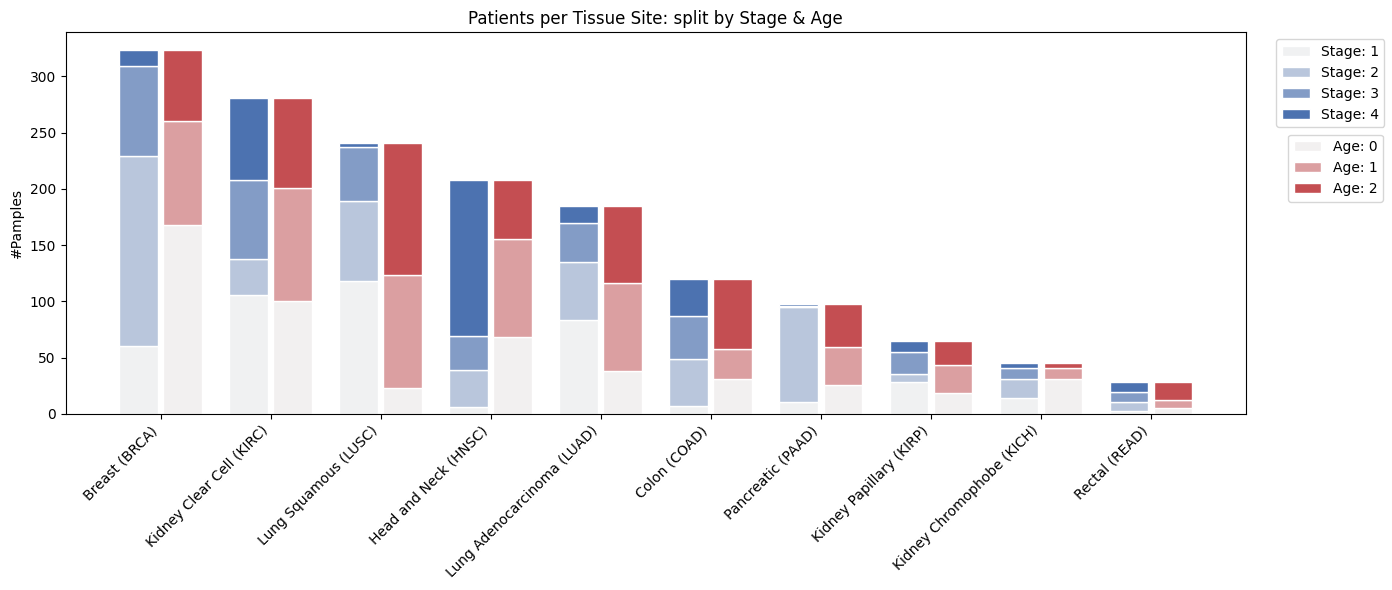

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# --- Load data ---
df = tcga_train
tissue_col = "project_id_x"
stage_col = "Stage"
age_col = "Age"

# --- Prepare stage pivot ---
tmp_stage = df[[tissue_col, stage_col]].dropna()
tmp_stage[stage_col] = tmp_stage[stage_col].astype(str)
pivot_stage = pd.pivot_table(
    tmp_stage, index=tissue_col, columns=stage_col, aggfunc="size", fill_value=0
)

# --- Prepare age pivot ---
tmp_age = df[[tissue_col, age_col]].dropna()
tmp_age[age_col] = tmp_age[age_col].astype(str)
pivot_age = pd.pivot_table(
    tmp_age, index=tissue_col, columns=age_col, aggfunc="size", fill_value=0
)

# --- Align tissue sites ---
tissues = df[tissue_col].dropna().unique()
pivot_stage = pivot_stage.reindex(tissues, fill_value=0)
pivot_age   = pivot_age.reindex(tissues, fill_value=0)

tissue_order = df[tissue_col].value_counts().index  # descending order
pivot_stage = pivot_stage.reindex(tissue_order, fill_value=0)
pivot_age   = pivot_age.reindex(tissue_order, fill_value=0)


# --- Colors ---
stage_colors = sns.light_palette("#4c72b0", n_colors=len(pivot_stage.columns))  # soft blues
age_colors   = sns.light_palette("#c44e52", n_colors=len(pivot_age.columns))   # soft reds


# --- Plot ---
fig, ax = plt.subplots(figsize=(14,6))
x = np.arange(len(tissues))

bar_width = 0.35
gap = 0.05
offset = bar_width/2 + gap/2  # ensures even spacing

# Stage stacked (left bars)
bottom = np.zeros(len(tissues))
for color, col in zip(stage_colors, pivot_stage.columns):
    ax.bar(x - offset, pivot_stage[col].values, bottom=bottom,
           width=bar_width, color=color, edgecolor="white")
    bottom += pivot_stage[col].values

# Age stacked (right bars)
bottom = np.zeros(len(tissues))
for color, col in zip(age_colors, pivot_age.columns):
    ax.bar(x + offset, pivot_age[col].values, bottom=bottom,
           width=bar_width, color=color, edgecolor="white")
    bottom += pivot_age[col].values

# Labels and ticks
ax.set_title("Patients per Tissue Site: split by Stage & Age")
ax.set_xlabel("")
ax.set_ylabel("#Pamples")

x = np.arange(len(tissue_order))
labels = [f"{tcga_map.get(code, code)} ({code[5:]})" for code in tissue_order]
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
#ax.set_xticklabels(tissue_order, rotation=45, ha="right")
#ax.set_xticks(x)
#ax.set_xticklabels(tissues, rotation=45, ha="right")

# Legends using Patch
stage_labels = [f"Stage: {c}" for c in pivot_stage.columns]
age_labels   = [f"Age: {c}" for c in pivot_age.columns]

stage_handles = [Patch(facecolor=color, edgecolor="white") for color in stage_colors]
age_handles   = [Patch(facecolor=color, edgecolor="white") for color in age_colors]

legend1 = ax.legend(stage_handles, stage_labels, title="",
                    bbox_to_anchor=(1.02, 1), loc="upper left")
ax.add_artist(legend1)
ax.legend(age_handles, age_labels, title="",
          bbox_to_anchor=(1.03, 0.75), loc="upper left")

plt.tight_layout()
plt.savefig('patient_num_barplot.png', dpi=300, bbox_inches="tight")
plt.show()


<Figure size 640x480 with 0 Axes>